In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
path = "myopia.csv"
df = pd.read_csv(path)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AGE        618 non-null    int64  
 1   SPHEQ      618 non-null    float64
 2   AL         618 non-null    float64
 3   ACD        618 non-null    float64
 4   LT         618 non-null    float64
 5   VCD        618 non-null    float64
 6   SPORTHR    618 non-null    int64  
 7   READHR     618 non-null    int64  
 8   COMPHR     618 non-null    int64  
 9   STUDYHR    618 non-null    int64  
 10  TVHR       618 non-null    int64  
 11  DIOPTERHR  618 non-null    int64  
 12  MOMMY      618 non-null    int64  
 13  DADMY      618 non-null    int64  
 14  MYOPIC     618 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 72.6 KB


In [4]:
# 2. Remove the "MYOPIC" column from the dataset
X = df.drop(columns=["MYOPIC"])

# 3. Standardize your dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2: Apply Dimensionality Reduction


In [5]:
# 1. Perform dimensionality reduction with PCA (preserve 90% variance)
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# How did the number of features change?
print(old_features := X.shape[1])
print(new_features := X_pca.shape[1])

14
10


How did the number of features change? The number of features was reduced from 14 to 10. This means that 10 principal components are sufficient to capture and preserve 90% of the dataset's total variance.

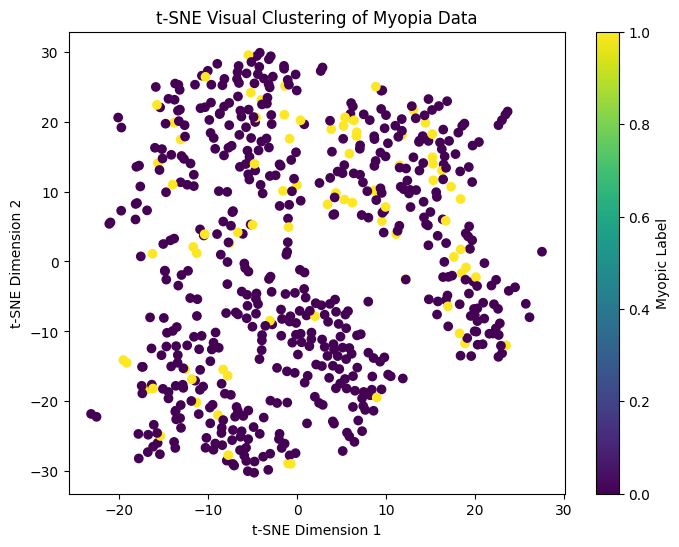

In [6]:
# 2. Further reduce dimensions with t-SNE
tsne = TSNE(learning_rate=250, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# 3. Create a scatter plot of the t-SNE output
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["MYOPIC"] if "MYOPIC" in df else None, cmap="viridis")
plt.title("t-SNE Visual Clustering of Myopia Data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Myopic Label")
plt.show()

Are there distinct clusters? No, there are no clearly distinct clusters. In the t-SNE scatter plot, the data points form one large, continuous mass rather than separating into isolated structural islands. Furthermore, the yellow points (myopic patients) are thoroughly mixed with the purple points, meaning the t-SNE alone does not cleanly segregate the groups visually.

3: Perform a Cluster Analysis with K-means

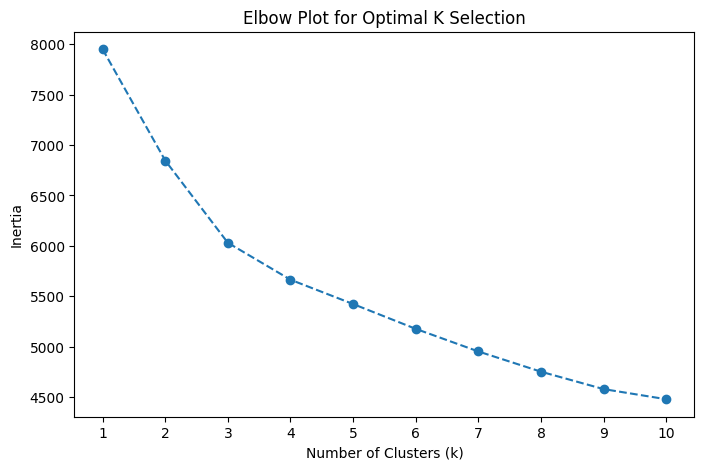

In [7]:
# Use a for loop to determine the inertia for each k between 1 through 10
inertia = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(X_pca)
    inertia.append(model.inertia_)

# Create an elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title("Elbow Plot for Optimal K Selection")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()


4: Make a Recommendation

Recommendation: Based on the analysis, the patients can be grouped into 3 distinct clusters as indicated by the inflection point in the K-means elbow plot. However, because the t-SNE visualization shows significant overlap between the patient profiles, these clusters are not naturally segregated in low-dimensional space and should be treated with clinical caution.